In [233]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from sklearn.manifold import TSNE

Импортируем датасет - это датасет, представляющий из себя граф научной публикации; и т к предстоит решать задачу классификации вершин, то будет достаточно одного графа для обзора; если граф окажется слишком большим - то можем и подграф взять

In [242]:
from torch_geometric.datasets import Coauthor

dataset = Coauthor(root='/tmp/Coauthor', name='CS')
graph = dataset[0]

В этом датасете классами являются области компьютерных наук

Выведем статистику по датасету

In [243]:
display(pd.DataFrame([[dataset, len(dataset), dataset.num_node_features, dataset.num_edge_features]],
                     columns=["Датасет",
                              "Количество графов",
                              "Количество признаков вершин",
                              "Количество признаков ребер",
                              ]).T)

,0
Датасет,"([(x, tensor([[0., 0., 0., ..., 0., 0., 0.],\..."
Количество графов,1
Количество признаков вершин,6805
Количество признаков ребер,0


Наш граф заранее не разбит на train/test/val части - и надо в этом графе дополнительно провести такое разбиение

Можно разбивать рандомно - но скорее всего столкнемся с тем, что train и test части будут сильно связаны, что для обучения модели нехорошо; поэтому используем bfs-подход, чтобы сильно связанные узлы попадали в одну из выборок, а не делились по 2-м выборкам train и test

In [250]:
from collections import deque # для классического BFS и нужен

def bfs_masks(graph, train_ratio=0.6, val_ratio=0.2):
    G = to_networkx(graph, to_undirected=True)
    train_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)

    visited = set()
    for start_node in range(graph.num_nodes):
        if start_node not in visited:
            queue = deque([start_node])
            while queue:
                node = queue.popleft()
                if node not in visited:
                    visited.add(node)
                    # Тут мы как раз распределяем по частям - train, test и val
                    if train_mask.sum() < train_ratio * graph.num_nodes:
                        train_mask[node] = True
                    elif val_mask.sum() < val_ratio * graph.num_nodes:
                        val_mask[node] = True
                    else:
                        test_mask[node] = True
                    queue.extend([n for n in G.neighbors(node) if n not in visited])

    graph.train_mask, graph.val_mask, graph.test_mask = train_mask, val_mask, test_mask
    return graph

graph = bfs_masks(graph)

In [245]:
# И теперь оценим количество ребер между множествами

def check_leakage(graph):

    edge_index = graph.edge_index
    cross_edges = 0

    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i].item(), edge_index[1, i].item()
        if (graph.train_mask[src] != graph.train_mask[dst] or
            graph.val_mask[src] != graph.val_mask[dst] or
            graph.test_mask[src] != graph.test_mask[dst]):
            cross_edges += 1

    print(f"Рёбра между множествами: {cross_edges}/{edge_index.shape[1]} ({cross_edges/edge_index.shape[1]:.1%})")
    return cross_edges

# Проверяем - 22.9 % в целом нормально; учтем это и скажем при выводе о результатах обучения
check_leakage(graph)

Рёбра между множествами: 37574/163788 (22.9%)


37574

#### Теперь - по самому графу

In [246]:

print(f'Number of nodes: {graph.num_nodes}')
print(f'Number of edges: {graph.num_edges}')
print(f'Average node degree: {graph.num_edges / graph.num_nodes:.2f}')
print(f'Number of training nodes: {graph.train_mask.sum()}')
print(f'Training node label rate: {int(graph.train_mask.sum()) / graph.num_nodes:.2f}')
print(f'Has isolated nodes: {graph.has_isolated_nodes()}')
print(f'Has self-loops: {graph.has_self_loops()}')
print(f'Is undirected: {graph.is_undirected()}')

# Т е граф на самом деле большой - можем для решения задачи классификации ограничиться подграфом

Number of nodes: 18333
Number of edges: 163788
Average node degree: 8.93
Number of training nodes: 11000
Training node label rate: 0.60
Has isolated nodes: False
Has self-loops: False
Is undirected: True


И для визуализации возьмем функции - для графа и для эмбеддингов (визуализируем их до обучения/после обучения)

In [247]:
def visualize_graph(G, color):
    plt.figure(figsize=(16, 8))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, with_labels=False,
                     node_color=color, node_size=50)
    plt.show()


def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(16, 8))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [253]:
from torch_geometric.data import Data
from torch_geometric.utils import subgraph


# Мало того, что надо подграф взять, так надо еще и классы вершин сохранить, какие были у вершин

def sub_graph(graph, node_indices):

    # Фильтруем рёбра
    edge_index, _ = subgraph(node_indices, graph.edge_index)

    # Создаём новый граф
    sub_g = Data(
        x=graph.x[node_indices],
        edge_index=edge_index,
        y=graph.y[node_indices]  # метки сохраняются
    )

    # Копируем маски если есть
    if hasattr(graph, 'train_mask'):
        sub_g.train_mask = graph.train_mask[node_indices]
    if hasattr(graph, 'val_mask'):
        sub_g.val_mask = graph.val_mask[node_indices]
    if hasattr(graph, 'test_mask'):
        sub_g.test_mask = graph.test_mask[node_indices]
    return sub_g


# Использование
node_indices = torch.arange(5000)
sub_g = sub_graph(graph, node_indices)
print(f"Подграф: {sub_g.num_nodes} узлов, {sub_g.num_edges} рёбер")
print(f"Метки: {sub_g.y.shape}, Классы: {torch.unique(sub_g.y)}")

Подграф: 5000 узлов, 14810 рёбер
Метки: torch.Size([5000]), Классы: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])


#### Визуализируем наш граф

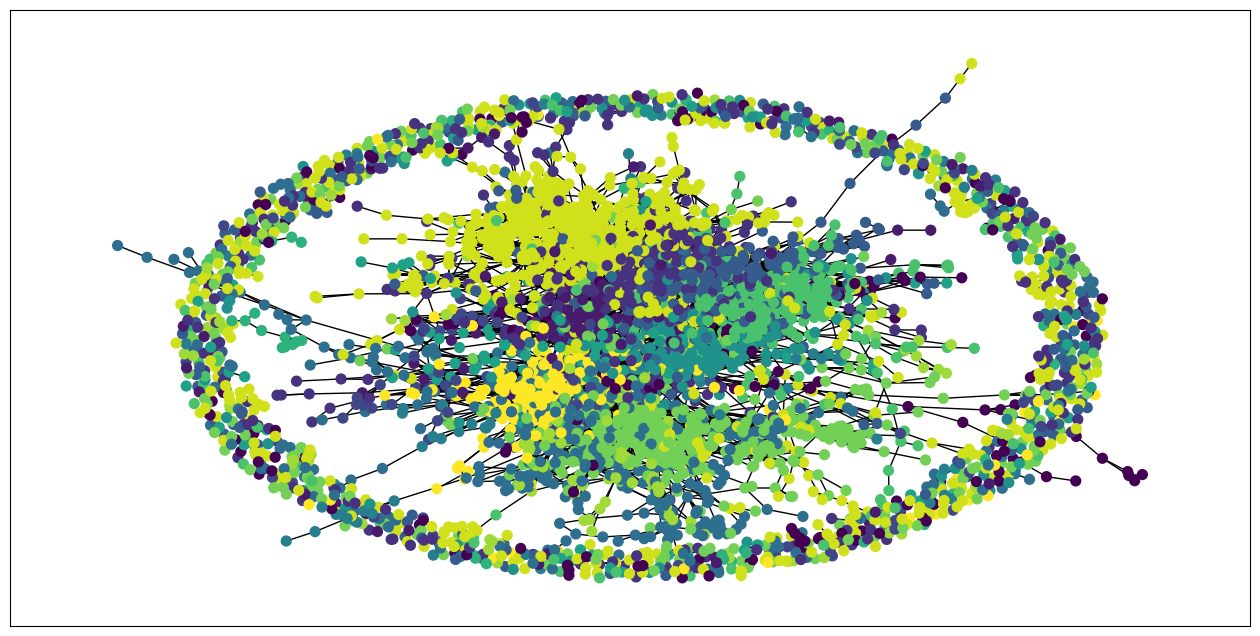

In [254]:
from torch_geometric.utils import to_networkx
G = to_networkx(sub_g, to_undirected=True)
visualize_graph(G, color=sub_g.y)

### 1. GCN- модель + подбор гиперпараметров

#### Построим модель GCN - в целом, возьмем baseline реализации и добавим несколько слоев

In [320]:
from torch_geometric.nn import GCNConv, BatchNorm
import torch.nn.functional as F

# По сравнению с baseline добавили еще один слой и BatchNorm
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, dataset.num_classes)
        self.bn1 = BatchNorm(hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)

    def forward(self, x, edge_index):
        # Первый блок
        x1 = self.conv1(x, edge_index)
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = F.dropout(x1, p=0.5, training=self.training)

        # Второй блок с residual connection
        x2 = self.conv2(x1, edge_index)
        x2 = self.bn2(x2)
        x2 = x2 + x1
        x2 = F.relu(x2)
        x2 = F.dropout(x2, p=0.5, training=self.training)

        x3 = self.conv3(x2, edge_index)
        return x3

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(6805, 16)
  (conv2): GCNConv(16, 16)
  (conv3): GCNConv(16, 15)
  (bn1): BatchNorm(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


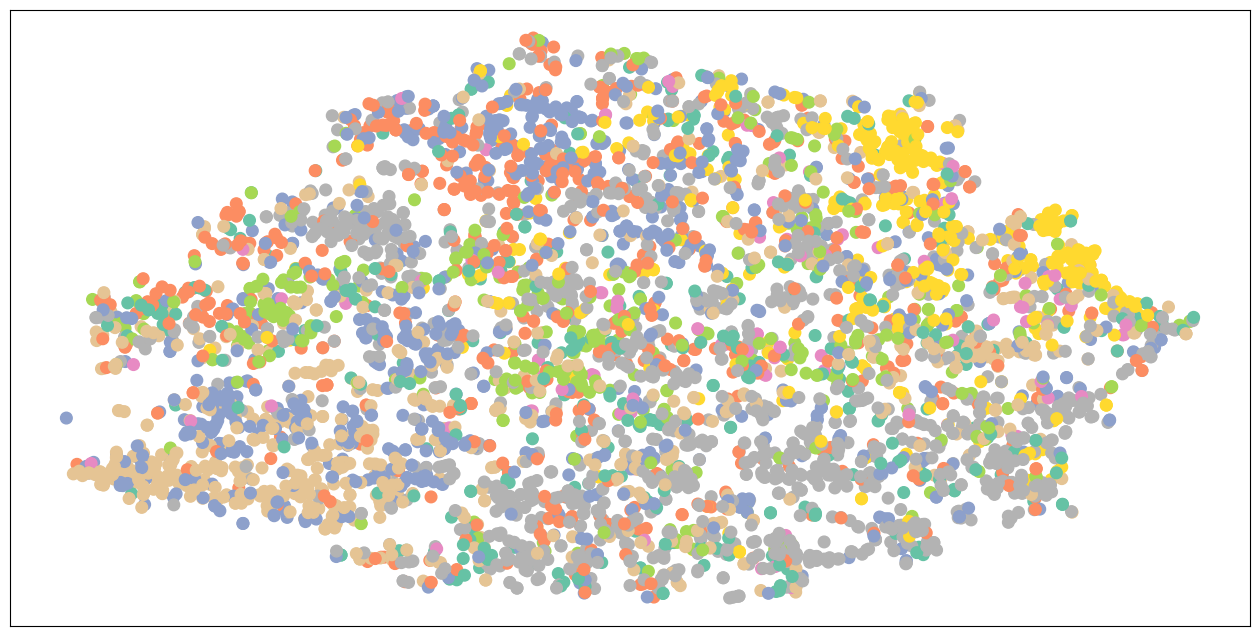

In [321]:
# Визуализируем необученные эмбеддинги
model.eval()
out = model(sub_g.x, sub_g.edge_index)
visualize(out, color=sub_g.y)

# Т е видно, что ничего не видно - никаких кластеров пока нет

#### Обучим модель и подберем гиперпараметры

In [322]:
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()  # Clear gradients.
      out = model(sub_g.x, sub_g.edge_index)  # Perform a single forward pass.
      loss = criterion(out[sub_g.train_mask], sub_g.y[sub_g.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      return loss

# На валидационной выборке будем гиперпараметры подбирать
def val():
      model.eval()
      out = model(sub_g.x, sub_g.edge_index)
      pred = out.argmax(dim=1)
      val_correct = pred[sub_g.val_mask] == sub_g.y[sub_g.val_mask]
      val_acc = int(val_correct.sum()) / int(sub_g.val_mask.sum())
      return val_acc

def test():
      model.eval()
      out = model(sub_g.x, sub_g.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[sub_g.test_mask] == sub_g.y[sub_g.test_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int(sub_g.test_mask.sum())  # Derive ratio of correct predictions.
      return test_acc

# Реализуем что-то в духе GridSearch

learning_rates = [0.1, 0.01, 0.001]
hidden_dims = [8, 16, 32]
weight_decays = [0, 5e-4, 1e-3]

best_acc = 0
best_params = {}

for lr in learning_rates:
    for hidden in hidden_dims:
        for wd in weight_decays:
            print(f"Testing lr={lr}, hidden={hidden}, wd={wd}")

            model = GCN(hidden_channels=hidden)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

            for epoch in range(100):
                train()

            acc = val()
            print(f"Accuracy: {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_params = {'lr': lr, 'hidden': hidden, 'wd': wd}

print(f"Best params: {best_params}, Accuracy: {best_acc:.4f}")

Testing lr=0.1, hidden=8, wd=0
Accuracy: 0.7093
Testing lr=0.1, hidden=8, wd=0.0005
Accuracy: 0.7413
Testing lr=0.1, hidden=8, wd=0.001
Accuracy: 0.6810
Testing lr=0.1, hidden=16, wd=0
Accuracy: 0.8346
Testing lr=0.1, hidden=16, wd=0.0005
Accuracy: 0.7843
Testing lr=0.1, hidden=16, wd=0.001
Accuracy: 0.8327
Testing lr=0.1, hidden=32, wd=0
Accuracy: 0.8492
Testing lr=0.1, hidden=32, wd=0.0005
Accuracy: 0.8510
Testing lr=0.1, hidden=32, wd=0.001
Accuracy: 0.8574
Testing lr=0.01, hidden=8, wd=0
Accuracy: 0.7239
Testing lr=0.01, hidden=8, wd=0.0005
Accuracy: 0.7002
Testing lr=0.01, hidden=8, wd=0.001
Accuracy: 0.7002
Testing lr=0.01, hidden=16, wd=0
Accuracy: 0.7870
Testing lr=0.01, hidden=16, wd=0.0005
Accuracy: 0.7806
Testing lr=0.01, hidden=16, wd=0.001
Accuracy: 0.7879
Testing lr=0.01, hidden=32, wd=0
Accuracy: 0.8556
Testing lr=0.01, hidden=32, wd=0.0005
Accuracy: 0.8656
Testing lr=0.01, hidden=32, wd=0.001
Accuracy: 0.8574
Testing lr=0.001, hidden=8, wd=0
Accuracy: 0.5850
Testing lr=

In [323]:
### Обучение с найденными гиперпараметрами

model = GCN(hidden_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0005)
for epoch in range(1, 131):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Epoch: 001, Loss: 3.4829
Epoch: 002, Loss: 1.6671
Epoch: 003, Loss: 1.3035
Epoch: 004, Loss: 1.0950
Epoch: 005, Loss: 0.9437
Epoch: 006, Loss: 0.8571
Epoch: 007, Loss: 0.7529
Epoch: 008, Loss: 0.7382
Epoch: 009, Loss: 0.6850
Epoch: 010, Loss: 0.6522
Epoch: 011, Loss: 0.6210
Epoch: 012, Loss: 0.5931
Epoch: 013, Loss: 0.5624
Epoch: 014, Loss: 0.5547
Epoch: 015, Loss: 0.5470
Epoch: 016, Loss: 0.5148
Epoch: 017, Loss: 0.5014
Epoch: 018, Loss: 0.4786
Epoch: 019, Loss: 0.4823
Epoch: 020, Loss: 0.4758
Epoch: 021, Loss: 0.4563
Epoch: 022, Loss: 0.4463
Epoch: 023, Loss: 0.4541
Epoch: 024, Loss: 0.4339
Epoch: 025, Loss: 0.4176
Epoch: 026, Loss: 0.4162
Epoch: 027, Loss: 0.4011
Epoch: 028, Loss: 0.3965
Epoch: 029, Loss: 0.3902
Epoch: 030, Loss: 0.3861
Epoch: 031, Loss: 0.3809
Epoch: 032, Loss: 0.3629
Epoch: 033, Loss: 0.3555
Epoch: 034, Loss: 0.3565
Epoch: 035, Loss: 0.3498
Epoch: 036, Loss: 0.3360
Epoch: 037, Loss: 0.3265
Epoch: 038, Loss: 0.3416
Epoch: 039, Loss: 0.3344
Epoch: 040, Loss: 0.3391


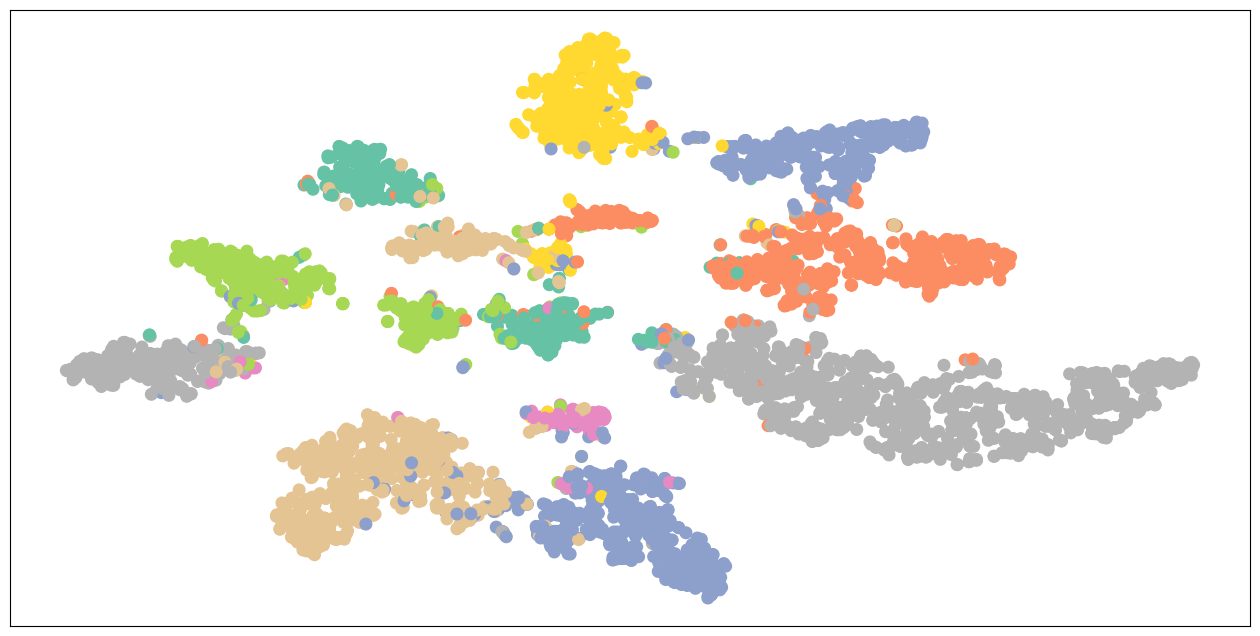

In [324]:
# А теперь обученные эмбеддинги визуализируем - и видим, что явно образовались кластеры:

model.eval()
out = model(sub_g.x, sub_g.edge_index)
visualize(out, color=sub_g.y)

Вывод: и accuracy получился приличный, и обученные эмбеддинги представляют собой кластеры - GCN действительно хорошо работает; конечно датасет не был изначально разделен на тренировочную/тестовые части; но думаю что реализованное разделение тоже неплохое и результатам можно верить

### 1. GCN- модель + реализация матричных вычислений

Формула для матричных вычислений из лекции была следующей: $H^{(l+1)} = \sigma(\tilde{A} H^{(k)} W^{(T)}_k+ H^{(k)}B^{T}_k)$

Т. е. пайлайн такой:
 - Реализуем слой GCNConv через матричные операции
 - Подставим этот слой в имеющуюся архитектуру выше; думаю гиперпараметры оставим те же
 - И сравним подходы

In [340]:
from torch.nn import Parameter


class MyGCNConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.W = Parameter(torch.Tensor(out_channels, in_channels))  # - веса для трансформации признаков
        self.B = Parameter(torch.Tensor(out_channels,
                                        in_channels))  # B^(l) - веса для residual connection (из второй части формулы как раз)
        self.bias = Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        # Инициализируем веса
        nn.init.xavier_uniform_(self.W)  # инициализация весов для преобразования признаков от соседей
        nn.init.xavier_uniform_(self.B)  # инициализация для residual connection
        nn.init.zeros_(self.bias)

    def forward(self, x, edge_index):
        num_nodes = x.size(0)

        A = torch.zeros(num_nodes, num_nodes)
        A[edge_index[0], edge_index[1]] = 1.0 # матрицу смежности делаем
        A = A + torch.eye(num_nodes)  # чтобы и свои признаки учитывать


        D = torch.sum(A, dim=1)                    # Степени узлов
        D_inv_sqrt = torch.pow(D, -0.5)                  # D^{-1/2}

        A_tilde = torch.diag(D_inv_sqrt) @ A

        return A_tilde @ (x @ self.W.T) + x @ self.B.T + self.bias

In [341]:
class NewGCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Уже используем нашу реализацию GCNConv

        self.conv1 = MyGCNConv(dataset.num_features, hidden_channels)
        self.conv2 = MyGCNConv(hidden_channels, hidden_channels)
        self.conv3 = MyGCNConv(hidden_channels, dataset.num_classes)

        self.bn1 = BatchNorm(hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)

    def forward(self, x, edge_index):
        # Первый блок
        x1 = self.conv1(x, edge_index)
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = F.dropout(x1, p=0.5, training=self.training)

        # Второй блок с residual connection
        x2 = self.conv2(x1, edge_index)
        x2 = self.bn2(x2)
        x2 = x2 + x1
        x2 = F.relu(x2)
        x2 = F.dropout(x2, p=0.5, training=self.training)

        # Выход
        x3 = self.conv3(x2, edge_index)
        return x3

In [343]:
# И обучаем все то же самое

my_model = NewGCN(hidden_channels=32)
optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01, weight_decay=0.0005)
criterion = torch.nn.CrossEntropyLoss()

def train():
      my_model.train()
      optimizer.zero_grad()  # Clear gradients.
      out = my_model(sub_g.x, sub_g.edge_index)  # Perform a single forward pass.
      loss = criterion(out[sub_g.train_mask], sub_g.y[sub_g.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      return loss

def val():
      my_model.eval()
      out = my_model(sub_g.x, sub_g.edge_index)
      pred = out.argmax(dim=1)
      val_correct = pred[sub_g.val_mask] == sub_g.y[sub_g.val_mask]
      val_acc = int(val_correct.sum()) / int(sub_g.val_mask.sum())
      return val_acc

def test():
      my_model.eval()
      out = my_model(sub_g.x, sub_g.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[sub_g.test_mask] == sub_g.y[sub_g.test_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int(sub_g.test_mask.sum())  # Derive ratio of correct predictions.
      return test_acc


for epoch in range(1, 131):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Epoch: 001, Loss: 5.6351
Epoch: 002, Loss: 1.8883
Epoch: 003, Loss: 1.4774
Epoch: 004, Loss: 1.2492
Epoch: 005, Loss: 1.1138
Epoch: 006, Loss: 1.0680
Epoch: 007, Loss: 0.9953
Epoch: 008, Loss: 0.9381
Epoch: 009, Loss: 0.8950
Epoch: 010, Loss: 0.8614
Epoch: 011, Loss: 0.8488
Epoch: 012, Loss: 0.7755
Epoch: 013, Loss: 0.7621
Epoch: 014, Loss: 0.7556
Epoch: 015, Loss: 0.7445
Epoch: 016, Loss: 0.6940
Epoch: 017, Loss: 0.7054
Epoch: 018, Loss: 0.6570
Epoch: 019, Loss: 0.6594
Epoch: 020, Loss: 0.6511
Epoch: 021, Loss: 0.6272
Epoch: 022, Loss: 0.6659
Epoch: 023, Loss: 0.6254
Epoch: 024, Loss: 0.6072
Epoch: 025, Loss: 0.5812
Epoch: 026, Loss: 0.5660
Epoch: 027, Loss: 0.5582
Epoch: 028, Loss: 0.5493
Epoch: 029, Loss: 0.5653
Epoch: 030, Loss: 0.5615
Epoch: 031, Loss: 0.5518
Epoch: 032, Loss: 0.5293
Epoch: 033, Loss: 0.5423
Epoch: 034, Loss: 0.5151
Epoch: 035, Loss: 0.5187
Epoch: 036, Loss: 0.5009
Epoch: 037, Loss: 0.4878
Epoch: 038, Loss: 0.4836
Epoch: 039, Loss: 0.4678
Epoch: 040, Loss: 0.4769


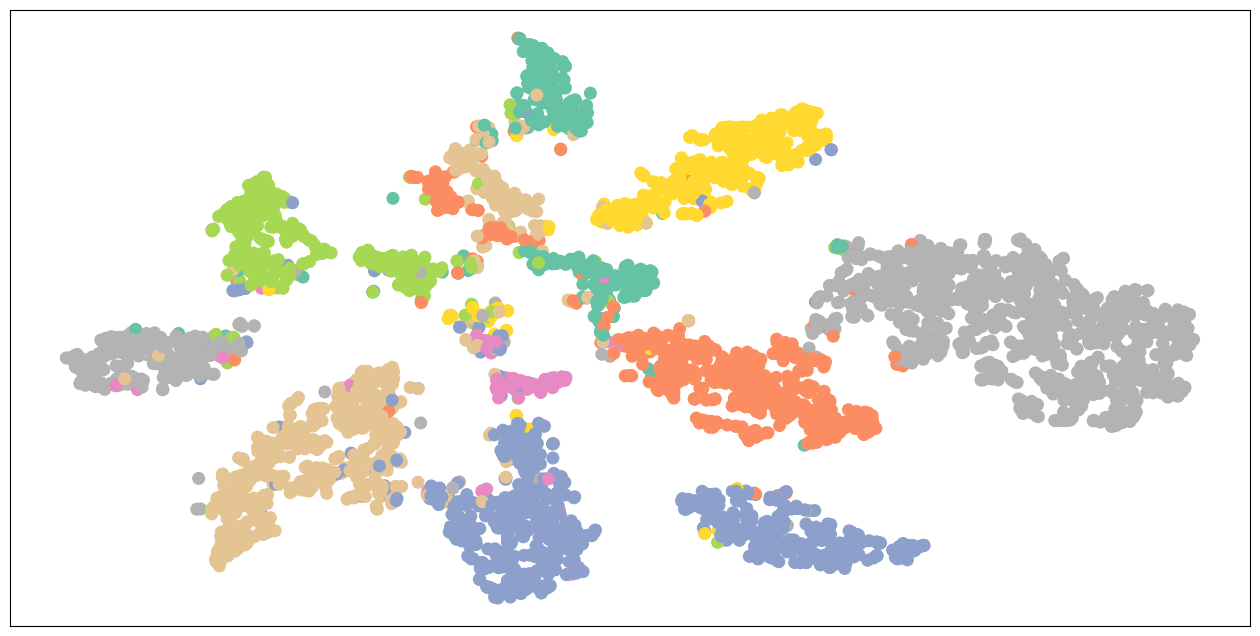

In [344]:
# Снова эмбеддинги

my_model.eval()
out = my_model(sub_g.x, sub_g.edge_index)
visualize(out, color=sub_g.y)

Вывод: самостоятельная реализация слоя тоже получилась вполне неплохой; accuracy получился очень похожим на первый случай; эмбеддинги также представляют собой кластеры, как и в первом случае - что видно выше